# **Introduction**
In today’s digital-first world, customers continuously share their experiences and opinions through online reviews, making sentiment analysis an important tool for understanding customer perception at scale. For airlines, these reviews provide valuable insights into passenger satisfaction, service quality, and recurring pain points, but manually analyzing thousands of reviews is inefficient and difficult to scale. This project aims to automatically classify US airline reviews based on their sentiment using traditional machine learning and deep learning approaches. The goal is to help identify customer dissatisfaction, understand overall passenger sentiment, and provide actionable insights that can support better service and customer-experience decisions.


In [192]:
# pip install pandas matplotlib seaborn
# pip install scikit-learn
# pip install nltk
# pip install emoji

In [193]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.util import ngrams
import emoji
import warnings
warnings.filterwarnings("ignore")

In [194]:
# Loading the dataset
df_original = pd.read_csv("D:/Python programming/Projects/Sentiment Analysis- US Airline Reviews/dataset/tweets.csv")

In [195]:
df_original.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [196]:
df_original.columns.tolist()

['tweet_id',
 'airline_sentiment',
 'airline_sentiment_confidence',
 'negativereason',
 'negativereason_confidence',
 'airline',
 'airline_sentiment_gold',
 'name',
 'negativereason_gold',
 'retweet_count',
 'text',
 'tweet_coord',
 'tweet_created',
 'tweet_location',
 'user_timezone']

For this sentiment analysis task, we will focus only on the `text` column as the input feature and `airline_sentiment` as the target variable, while excluding the remaining columns from the modeling process.


In [197]:
df = df_original[["text","airline_sentiment"]]

## Inspecting the data

In [198]:
df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials to the experience... tacky.,positive
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,neutral
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",negative
4,@VirginAmerica and it's a really big bad thing about it,negative


In [199]:
df.shape

(14640, 2)

In [200]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   text               14640 non-null  str  
 1   airline_sentiment  14640 non-null  str  
dtypes: str(2)
memory usage: 228.9 KB
None


In [201]:
# Checking for null values
display(df.isnull().sum())

text                 0
airline_sentiment    0
dtype: int64

In [202]:
# Checking for duplicate
df[df.duplicated()==True].head(15)

,text,airline_sentiment
331,@VirginAmerica Thanks!,positive
515,@united thanks,positive
1477,@united thank you!,positive
1864,@united thank you,positive
1938,@united thank you,positive
1969,@united thank you!,positive
2285,@united thanks,positive
2647,@united thank you.,positive
2859,@united thanks,positive
2890,@united Thanks!,positive


In [203]:
# Removing the duplicates
print(f"Number of duplicates: {df.duplicated().sum()}")
print(f"duplicated entries has been removed")
df.drop_duplicates(inplace=True)
print("number of duplicates: ", df.duplicated().sum())

Number of duplicates: 188
duplicated entries has been removed
number of duplicates:  0


# EDA

In [204]:
# Checking for unique values
target = "airline_sentiment"
print(df[target].unique().tolist())

['neutral', 'positive', 'negative']


In [205]:
print((df[target].value_counts()*100)/len(df))

airline_sentiment
negative    62.877110
neutral     21.221976
positive    15.900913
Name: count, dtype: float64


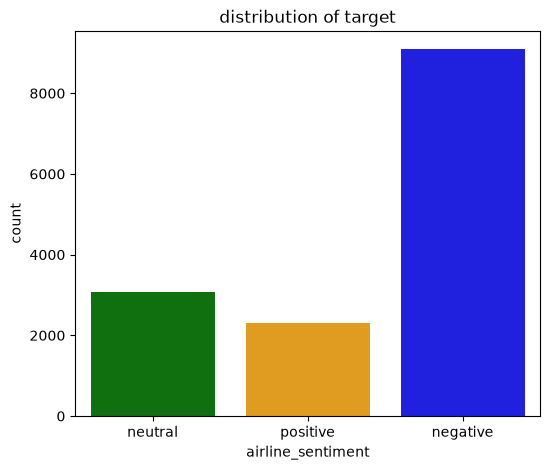

In [206]:
plt.figure(figsize=(6,5))
sns.countplot(df, x = df[target], palette=["green", "orange", "blue"], hue=target)
plt.title("distribution of target")
plt.show()

#### Now understanding the text column

In [207]:
# Checking lenghts of tweets
df["word_count"] = df["text"].str.split().str.len()
df.groupby(target)["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
airline_sentiment,,,,,,,,
negative,9087.0,19.690547,5.947176,2.0,16.0,21.0,24.0,36.0
neutral,3067.0,14.440822,6.946962,2.0,9.0,14.0,20.0,31.0
positive,2298.0,14.248042,6.919294,2.0,9.0,14.0,20.0,31.0


In [208]:
# Understanding the distribution of tokens over the corpus
text = df["text"].str.lower() # converting the text into the lowercase
tokens_per_tweet = text.apply(lambda x: re.findall(r"[a-z]+" , x)) # tokenisation
tokens = [word for tweet in tokens_per_tweet for word in tweet]
unique_tokens = list(set(tokens))
print(f"Total number of tokens: {len(tokens)}")
print(f"Total number of unique tokens in the corpus: {len(unique_tokens)}")


Total number of tokens: 261350
Total number of unique tokens in the corpus: 13661


In [209]:
word_freq = dict(Counter(word for tweet in tokens_per_tweet for word in tweet))

In [210]:

print("Top 20 most frequent words in the corpus before removing stopwords : ")
word_freq = dict(sorted(word_freq.items(), key = lambda x: x[1], reverse = True))
top_20 = list(word_freq.items())[:20]
top_20


Top 20 most frequent words in the corpus before removing stopwords : 


[('to', 8572),
 ('i', 6660),
 ('the', 6001),
 ('a', 4593),
 ('you', 4337),
 ('united', 4151),
 ('for', 3958),
 ('flight', 3914),
 ('on', 3776),
 ('and', 3702),
 ('t', 3358),
 ('my', 3244),
 ('usairways', 3039),
 ('americanair', 2818),
 ('is', 2807),
 ('in', 2572),
 ('southwestair', 2451),
 ('it', 2391),
 ('jetblue', 2384),
 ('of', 2098)]

In [211]:
stop_words = list(ENGLISH_STOP_WORDS)
tokens_without_sw = [word for tweet in tokens_per_tweet  for word in tweet if word not in stop_words]
print(f"Total number of tokens after removing stopwords: {len(tokens_without_sw)}")
unique_tokens_without_sw = list(set(tokens_without_sw))
print(f"Total number fo unique tokens after removing the stopwords: {len(unique_tokens_without_sw)}")


Total number of tokens after removing stopwords: 140571
Total number fo unique tokens after removing the stopwords: 13378


In [212]:
word_freq_wsw = dict(Counter(tokens_without_sw))
word_freq_wsw = sorted(word_freq_wsw.items(), key=lambda x: x[1], reverse=True)

In [213]:
print("Top 20 most frequent words after removing stop words: ")
word_freq_wsw[:20]

Top 20 most frequent words after removing stop words: 


[('united', 4151),
 ('flight', 3914),
 ('t', 3358),
 ('usairways', 3039),
 ('americanair', 2818),
 ('southwestair', 2451),
 ('jetblue', 2384),
 ('s', 1579),
 ('http', 1146),
 ('cancelled', 1046),
 ('thanks', 1045),
 ('just', 965),
 ('service', 960),
 ('help', 868),
 ('time', 786),
 ('m', 761),
 ('customer', 750),
 ('amp', 676),
 ('hours', 676),
 ('flights', 645)]

### N-grams Analysis

In [214]:
bigram_freq = dict(Counter(bigram for tweet in tokens_per_tweet for bigram in ngrams(tweet, 2)))
bigram_freq = list(sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True))
trigram_freq = dict(Counter(trigram for tweet in tokens_per_tweet for trigram in ngrams(tweet, 3)))
trigram_freq = list(sorted(trigram_freq.items(), key=lambda x: x[1], reverse=True))

In [215]:
print("Top 20 most frequent bigram: ")
bigram_freq[:20]

Top 20 most frequent bigram: 


[(('t', 'co'), 1202),
 (('http', 't'), 1146),
 (('i', 'm'), 706),
 (('customer', 'service'), 556),
 (('thank', 'you'), 546),
 (('on', 'the'), 543),
 (('can', 't'), 537),
 (('on', 'hold'), 511),
 (('it', 's'), 500),
 (('cancelled', 'flightled'), 499),
 (('my', 'flight'), 482),
 (('to', 'get'), 482),
 (('i', 'have'), 473),
 (('don', 't'), 463),
 (('for', 'the'), 453),
 (('united', 'i'), 429),
 (('thanks', 'for'), 391),
 (('to', 'be'), 364),
 (('in', 'the'), 362),
 (('for', 'a'), 348)]

In [216]:
print("Top 20 most frequent trigram: ")
trigram_freq[:20]

Top 20 most frequent trigram: 


[(('http', 't', 'co'), 1146),
 (('on', 'hold', 'for'), 236),
 (('been', 'on', 'hold'), 165),
 (('i', 've', 'been'), 147),
 (('thank', 'you', 'for'), 145),
 (('jetblue', 'our', 'fleet'), 145),
 (('our', 'fleet', 's'), 145),
 (('fleet', 's', 'on'), 145),
 (('s', 'on', 'fleek'), 145),
 (('thanks', 'for', 'the'), 144),
 (('on', 'fleek', 'http'), 143),
 (('fleek', 'http', 't'), 143),
 (('i', 'can', 't'), 137),
 (('i', 'don', 't'), 123),
 (('can', 't', 'get'), 105),
 (('was', 'cancelled', 'flightled'), 104),
 (('i', 'need', 'to'), 98),
 (('on', 'the', 'phone'), 95),
 (('flight', 'booking', 'problems'), 89),
 (('i', 'have', 'to'), 89)]

The n-gram analysis reveals both meaningful domain-specific phrases and textual noise. Phrases such as “customer service,” “thank you,” “on hold,” and “flight booking problems” provide useful contextual information for sentiment analysis, while patterns such as “http t co,” “i m,” and “can t” indicate the presence of URLs and split contractions. These findings suggest that appropriate text preprocessing is needed before feature extraction, while preserving sentiment-critical information such as negation.

### Noise Analysis

In [217]:
# Original tweets
text = df["text"].fillna("").astype(str)

# Total number of tweets
n = len(text)

# 1. URLs
url_pattern = r"https?://\S+|www\.\S+"
url_count = text.str.count(url_pattern).sum()
url_tweets = text.str.contains(url_pattern, regex=True).sum()

# 2. Mentions
mention_pattern = r"@\w+"
mention_count = text.str.count(mention_pattern).sum()
mention_tweets = text.str.contains(mention_pattern, regex=True).sum()

# 3. Hashtags
hashtag_pattern = r"#\w+"
hashtag_count = text.str.count(hashtag_pattern).sum()
hashtag_tweets = text.str.contains(hashtag_pattern, regex=True).sum()

# 4. Sentiment-related punctuation (! and ?)
punctuation_pattern = r"[!?]"
punctuation_count = text.str.count(punctuation_pattern).sum()
punctuation_tweets = text.str.contains(punctuation_pattern, regex=True).sum()

# 5. Numbers
number_pattern = r"\d+"
number_count = text.str.count(number_pattern).sum()
number_tweets = text.str.contains(number_pattern, regex=True).sum()

# 6. Repeated characters
# Example: sooo, goooood
repeated_pattern = r"([a-zA-Z])\1{2,}"
repeated_count = text.apply(
    lambda x: len(re.findall(repeated_pattern, x))).sum()
repeated_tweets = text.apply(
    lambda x: bool(re.search(repeated_pattern, x))).sum()

# 7. HTML entities
# Example: &amp;, &quot;
html_pattern = r"&[a-zA-Z]+;"
html_count = text.str.count(html_pattern).sum()
html_tweets = text.str.contains(html_pattern, regex=True).sum()

# 8. Contractions
# Example: I'm, don't, can't, isn't
contraction_pattern = r"\b\w+(?:'|\u2019)\w+\b"
contraction_count = text.apply(lambda x: len(re.findall(contraction_pattern, x))).sum()
contraction_tweets = text.apply(lambda x: bool(re.search(contraction_pattern, x))).sum()

# 9. Emojis
emoji_count = text.apply(lambda x: len(emoji.emoji_list(x))).sum()
emoji_tweets = text.apply(lambda x: len(emoji.emoji_list(x)) > 0).sum()

# Create DataFrame
noise_summary = pd.DataFrame({"Noise Type": ["URLs","Mentions","Hashtags","Sentiment Punctuation","Numbers","Repeated Characters","HTML Entities",
                                             "Contractions","Emojis"],
    
                              "Count": [url_count,mention_count,hashtag_count,punctuation_count,number_count,repeated_count,html_count,
                                        contraction_count,emoji_count],

                               "Tweets Containing": [url_tweets,mention_tweets,hashtag_tweets,punctuation_tweets,number_tweets,repeated_tweets,
                                                     html_tweets,contraction_tweets,emoji_tweets]})

# Percentage of tweets containing each element
noise_summary["Percentage of Tweets"] = (noise_summary["Tweets Containing"] / n * 100).round(2)

# Display result
noise_summary

,Noise Type,Count,Tweets Containing,Percentage of Tweets
0,URLs,1202,1164,8.05
1,Mentions,16300,14452,100.00
2,Hashtags,3469,2352,16.27
3,Sentiment Punctuation,9874,6220,43.04
4,Numbers,10006,5816,40.24
5,Repeated Characters,116,107,0.74
6,HTML Entities,816,716,4.95
7,Contractions,5617,4576,31.66
8,Emojis,973,490,3.39


The noise analysis shows that tweets contain substantial amounts of non-standard text, particularly mentions, punctuation, numbers, and contractions. Some elements, such as URLs and HTML entities, are primarily noise and can be cleaned, whereas hashtags, emojis, punctuation, and contractions may contain sentiment information and should be handled carefully. In particular, the high prevalence of mentions (100%) and contractions (31.66%) suggests that preprocessing decisions should be based on their role in the sentiment context rather than applying generic text-cleaning rules.

### Manual Inspection

In [218]:
pd.set_option("display.max_colwidth", None)

for sentiment in ["positive", "neutral", "negative"]:
    print(f"\n{'='*20} {sentiment.upper()} {'='*20}")
    sample = df[df["airline_sentiment"] == sentiment].sample(5, random_state=42)
    for i, tweet in enumerate(sample["text"], 1):
        print(f"\n{i}. {tweet}")


==================== POSITIVE ====================

1. @SouthwestAir LOVE your TV ad with the girl dancing. Makes me laugh every time, AND now I want to take a trip! :-)

2. @AmericanAir Thanks! He is.

3. @united My favorite way to travel! Thank you! http://t.co/vGN2X1ckg0

4. @SouthwestAir Thanks a ton!

5. @united you all do a wonderful job today. Got my wife, daughter, and myself from PGH to Orlando after out flight was delayed luggage and all

==================== NEUTRAL ====================

1. @SouthwestAir Hi! Winter Wx Advisory issued for STL. Snow &amp; Ice &amp; Cold, oh my! Will you issue a travel advisory for that?

2. @united I guess that's too much ask, huh?

3. @SouthwestAir please reply to my DM ♥️

4. @SouthwestAir has the winner for #DestinationDragons been announced yet? If not when will they be??

5. @AmericanAir why is it most first class passengers now request the sand which from coach ?

==================== NEGATIVE ====================

1. @JetBlue u guys ha

### Preprocessing decisions based on EDA


1. Convert all tweets to **lowercase** to treat different cases of the same word identically.

2. Remove **URLs** , **Mentions**, **Email addresses**, **HTML entities**, **Punctuation:** because they generally provide little sentiment information and introduce noisy tokens.

7. **Emojis:** Although emojis contains sentiment information but remove them because they occur in only 3.39% of tweets and are need special technique to be used in model.

8. **Numbers:** Remove numbers because they are mainly flight numbers, times, dates, and similar contextual information rather than sentiment.

10. **Contractions:** Expand contractions to preserve their meaning, e.g., `don't → do not` and `can't → cannot`.

11. **Repeated characters:** Normalize repeated characters to reduce spelling variations such as `goooood` and `soooo`.

12. **Stopwords:** Retain stopwords because removing words such as `not`, `no`, and `never` can destroy sentiment information.

13. **Stemming:** Will be tested on baseline model and then will decide.

14. **Lemmatization:** Will be tested on baseling model and then will decide.

15. **Extra whitespace:** Remove unnecessary whitespace created during preprocessing. *Example: `great   service   today` → `great service today`*